In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from IPython.display import clear_output
from matplotlib import cm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import PowerTransformer
from scipy.stats import norm
from scipy.optimize import minimize, differential_evolution


In [21]:
# Load all data
folder = Path(r'C:\Users\Dave Amin\Documents\docs-Sync\Career\2025-10 IC AI course\Modules\Capstone2\initial_data')
folder2 = Path(r'function_1')

def load_data():
    file_path_inputs =  folder / folder2 / rf"initial_inputs.npy"
    file_path_outputs = folder / folder2 / rf"initial_outputs.npy"
    X = np.load(file_path_inputs)
    Y = np.load(file_path_outputs)
    print('Initial data :','X.shape', X.shape, 'Y.shape', Y.shape)
    
    X_new_point = np.array([0.693878, 0.877551], dtype=np.float64)
    Y_new_point = np.array([1.3147995487661745e-46], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 1 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.409284, 0.912102], dtype=np.float64)
    Y_new_point = np.array([-2.847560735102855e-90], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 2 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.766388, 0.766134], dtype=np.float64)
    Y_new_point = np.array([4.46725784334253e-27], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 3 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.336568, 0.148632], dtype=np.float64)
    Y_new_point = np.array([1.4821968166523373e-58], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 4 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.067874, 0.653420], dtype=np.float64)
    Y_new_point = np.array([3.392454081417645e-127], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 5 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.721892, 0.724327], dtype=np.float64)
    Y_new_point = np.array([4.742275614073206e-13], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 6 :','X.shape', X.shape, 'Y.shape', Y.shape)

    # next week new values go here !!!!
  
    return X,Y

X,Y = load_data()

Initial data : X.shape (10, 2) Y.shape (10,)
Added week 1 : X.shape (11, 2) Y.shape (11,)
Added week 2 : X.shape (12, 2) Y.shape (12,)
Added week 3 : X.shape (13, 2) Y.shape (13,)
Added week 4 : X.shape (14, 2) Y.shape (14,)
Added week 5 : X.shape (15, 2) Y.shape (15,)
Added week 6 : X.shape (16, 2) Y.shape (16,)


In [22]:
# print('X.shape', X.shape)
# print('X col1 min',np.min(X[:, 0]), 'max',np.max(X[:, 0]))
# print('X col2 min',np.min(X[:, 1]), 'max',np.max(X[:, 1]))
# print('Y.shape', Y.shape)
print("Min Y =",min(Y),"\nMax Y =",max(Y))

Min Y = -0.0036060626443634764 
Max Y = 4.742275614073206e-13


In [23]:
print("X",X)
print("Y",Y)

X [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.693878   0.877551  ]
 [0.409284   0.912102  ]
 [0.766388   0.766134  ]
 [0.336568   0.148632  ]
 [0.067874   0.65342   ]
 [0.721892   0.724327  ]]
Y [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.31479955e-046 -2.84756074e-090
  4.46725784e-027  1.48219682e-058  3.39245408e-127  4.74227561e-013]


In [6]:
def heat_scatter(X,Y):
    plt.figure(figsize=(10, 7))
    
    # We use SymLogNorm because your data has negatives and extremely small positives
    norm = colors.SymLogNorm(linthresh=1e-20, linscale=1, vmin=Y.min(), vmax=Y.max())
    
    scatter = plt.scatter(X[:, 0], X[:, 1], c=Y, s=200, edgecolors='black', 
                          cmap='RdYlBu', norm=norm)
    
    # Add labels for each point's order (1 to 10)
    for i, txt in enumerate(range(1, len(Y) + 1)):
        plt.annotate(txt, (X[i, 0]+0.02, X[i, 1]+0.02))
    plt.colorbar(scatter, label='Y value (Symmetric Log Scale)')
    plt.xlabel('Input Feature 1 ($x_1$)')
    plt.ylabel('Input Feature 2 ($x_2$)')
    plt.title('Contest Data: Sample Locations and Observations')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

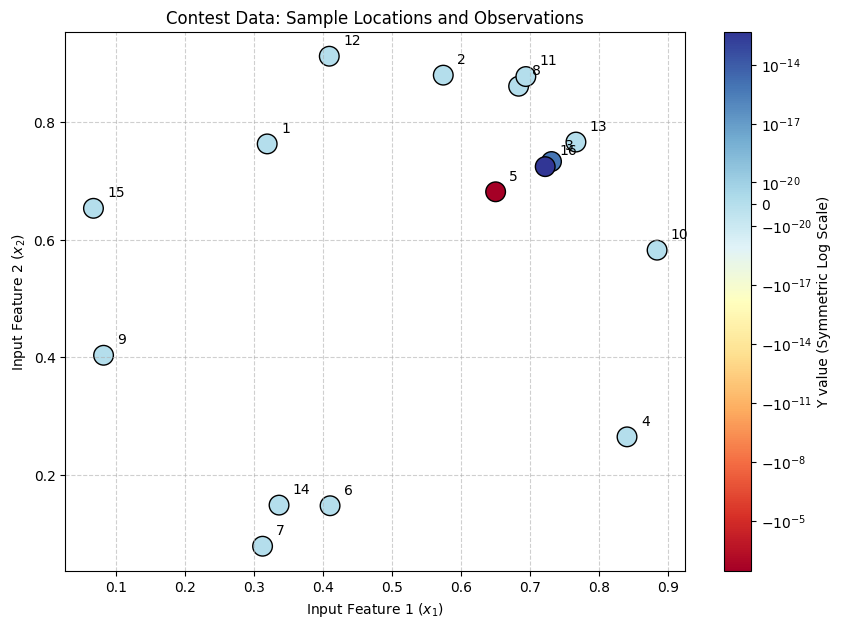

In [7]:
heat_scatter(X,Y)

In [8]:
# def plot3Dprediction(X,Y,model):
#     import numpy as np
#     import matplotlib.pyplot as plt
#     from matplotlib import cm
    
#     # 1. Determine the bounds of your loaded data for the grid
#     # 2. Create a dense grid for predictions
#     # We use 50x50 points to create a smooth surface
#     x1_linspace = np.linspace(0, 1, 50)
#     x2_linspace = np.linspace(0, 1, 50)
#     X1_grid, X2_grid = np.meshgrid(x1_linspace, x2_linspace)
    
#     # Flatten the grid to feed into the model
#     x_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
    
#     # 3. Predict using your fitted model
#     y_pred, std = model.predict(x_test, return_std=True)
    
#     # Reshape predictions back into the grid shape for plotting
#     Z_mean = y_pred.reshape(X1_grid.shape)
#     Z_std = std.reshape(X1_grid.shape)
    
#     # 4. Create the Visualization
#     fig = plt.figure(figsize=(16, 6))
    
#     # --- Subplot 1: 3D Surface of Predicted Mean ---
#     ax1 = fig.add_subplot(121, projection='3d')
#     surf = ax1.plot_surface(X1_grid, X2_grid, Z_mean, cmap='viridis', alpha=0.8, edgecolor='none')
#     ax1.scatter(X[:, 0], X[:, 1], Y, color='red', marker='x', s=50, label='Actual Data')
#     ax1.set_title('GP Predicted Mean Surface')
#     ax1.set_zlabel('Output Y')
#     fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
    
#     # --- Subplot 2: Heatmap of Uncertainty (Std Dev) ---
#     ax2 = fig.add_subplot(122)
#     contour = ax2.contourf(X1_grid, X2_grid, Z_std, levels=20, cmap='YlOrRd')
#     # contour = ax2.contourf(X1_grid, X2_grid, Z_mean, levels=20, cmap='YlOrRd')
#     ax2.scatter(X[:, 0], X[:, 1], c='black', marker='+', alpha=0.5)
#     ax2.set_title('Model Uncertainty (Std Dev)')
#     ax2.set_xlabel('Input Feature 1')
#     ax2.set_ylabel('Input Feature 2')
#     fig.colorbar(contour, ax=ax2, label='Standard Deviation')
    
#     plt.tight_layout()
#     plt.show()

In [9]:
def plot3Dprediction2(X,Y, y_pred, std, X1_grid, X2_grid):
    # Reshape predictions back into the grid shape for plotting
    Z_mean = y_pred.reshape(X1_grid.shape)
    Z_std = std.reshape(X1_grid.shape)
    
    # 4. Create the Visualization
    fig = plt.figure(figsize=(16, 6))
    
    # --- Subplot 1: 3D Surface of Predicted Mean ---
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(X1_grid, X2_grid, Z_mean, cmap='viridis', alpha=0.8, edgecolor='none')
    ax1.scatter(X[:, 0], X[:, 1], Y, color='red', marker='x', s=50, label='Actual Data')
    ax1.set_title('GP Predicted Mean Surface')
    ax1.set_zlabel('Output Y')
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
    
    # --- Subplot 2: Heatmap of Uncertainty (Std Dev) ---
    ax2 = fig.add_subplot(122)
    contour = ax2.contourf(X1_grid, X2_grid, Z_std, levels=20, cmap='YlOrRd')
    # contour = ax2.contourf(X1_grid, X2_grid, Z_mean, levels=20, cmap='YlOrRd')
    ax2.scatter(X[:, 0], X[:, 1], c='black', marker='+', alpha=0.5)
    ax2.set_title('Model Uncertainty (Std Dev)')
    ax2.set_xlabel('Input Feature 1')
    ax2.set_ylabel('Input Feature 2')
    fig.colorbar(contour, ax=ax2, label='Standard Deviation')
    
    plt.tight_layout()
    plt.show()

In [10]:
def plot_2d_uncertainty(model, X_train, next_point, bounds=[(0, 1), (0, 1)]):
    # 1. Create a 2D meshgrid
    res = 100 
    x1 = np.linspace(bounds[0][0], bounds[0][1], res)
    x2 = np.linspace(bounds[1][0], bounds[1][1], res)
    X1, X2 = np.meshgrid(x1, x2)
    grid = np.vstack([X1.ravel(), X2.ravel()]).T
    
    # 2. Get uncertainty (sigma)
    _, sigma = model.predict(grid, return_std=True)
    Sigma = sigma.reshape(X1.shape)
    
    # 3. Setup Plot
    plt.figure(figsize=(10, 8))
    
    # Plot the uncertainty background
    contour = plt.contourf(X1, X2, Sigma, levels=20, cmap='viridis', alpha=0.8)
    plt.colorbar(contour, label='Uncertainty (Sigma)')
    
    # 4. Plot PREVIOUS samples (Red Circles)
    plt.scatter(X_train[:, 0], X_train[:, 1], color='red', edgecolors='white', 
                label='Sampled Points', s=60)
    
    # 5. Plot the NEXT proposed point (Lime Star)
    plt.scatter(next_point[0], next_point[1], color='lime', marker='*', s=300, 
                edgecolors='black', label='Next Point (res.x)', zorder=5)
    
    plt.title("Model Uncertainty and Next Suggested Point")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()
    for i, txt in enumerate(range(1, len(Y) + 1)):
        plt.annotate(txt, (X[i, 0]+0.02, X[i, 1]+0.02))
    plt.show()

# --- Execution ---
# plot_2d_uncertainty(model, X, res.x)


In [11]:
def plot_results(model, X_train, next_point):
    res = 100 
    x1 = np.linspace(0, 1, res)
    x2 = np.linspace(0, 1, res)
    X1, X2 = np.meshgrid(x1, x2)
    grid = np.vstack([X1.ravel(), X2.ravel()]).T
    
    mu, sigma = model.predict(grid, return_std=True)
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Predicted Mean (The "Likely Sources")
    c1 = ax[0].contourf(X1, X2, mu.reshape(X1.shape), levels=20, cmap='magma')
    ax[0].scatter(X_train[:, 0], X_train[:, 1], c='white', edgecolors='black', label='Past Samples')
    ax[0].scatter(next_point[0], next_point[1], c='lime', marker='*', s=200, label='Next Target')
    ax[0].set_title("Predicted Contamination (Transformed Space)")
    fig.colorbar(c1, ax=ax[0])
    
    # Plot 2: Uncertainty (Where weak sources might hide)
    c2 = ax[1].contourf(X1, X2, sigma.reshape(X1.shape), levels=20, cmap='viridis')
    ax[1].scatter(X_train[:, 0], X_train[:, 1], c='red', edgecolors='white')
    ax[1].scatter(next_point[0], next_point[1], c='lime', marker='*', s=200)
    ax[1].set_title("Model Uncertainty (Search Priority)")
    fig.colorbar(c2, ax=ax[1])
    
    plt.legend()
    for i, txt in enumerate(range(1, len(Y) + 1)):
        plt.annotate(txt, (X[i, 0]+0.02, X[i, 1]+0.02))

    plt.show()


## New Code - 19 Mar - v4

In [26]:
X,Y = load_data()

# --- 2. Preprocessing ---
Y_clipped = np.clip(Y, 0, None)
pt = PowerTransformer(method='yeo-johnson', standardize=True)
Y_transformed = pt.fit_transform(Y_clipped.reshape(-1, 1)).ravel()

# --- 3. Stable Kernel Configuration ---
# Fixing the length_scale prevents the "spike" collapse and allows smooth hill-climbing.
# VERSION 4
# kernel = C(1.0) * Matern(
#     length_scale=0.02, 
#     length_scale_bounds="fixed", 
#     nu=1.5 
# ) + WhiteKernel(noise_level=1e-12)

# Updated Kernel for the next iteration: (VERSION 5)
kernel = C(1.0) * Matern(
    length_scale=0.02, 
    length_scale_bounds="fixed", 
    nu=1.5 
) + WhiteKernel(noise_level=1e-12, noise_level_bounds=(1e-15, 1e-8))


model = GaussianProcessRegressor(kernel=kernel, random_state=42)
model.fit(X, Y_transformed)

# --- 4. Acquisition Function: Expected Improvement (Pure Maximization) ---
current_best_transformed = np.max(Y_transformed)

def expected_improvement(x, model, best_y, xi=0.0001): 
    # Extremely low xi focuses entirely on beating the peak.
    x = x.reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    if sigma <= 1e-12: return 0.0
    
    imp = mu - best_y - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei[0]

# --- 5. Local Zoom Optimizer ---
# We center the search on your 4.74e-13 point and search only a small radius.
best_known_x = [0.721892, 0.724327]
zoom_radius = 0.08

bounds = [
    (max(0, best_known_x[0] - zoom_radius), min(1, best_known_x[0] + zoom_radius)),
    (max(0, best_known_x[1] - zoom_radius), min(1, best_known_x[1] + zoom_radius))
]

def min_obj(x):
    return -expected_improvement(x, model, current_best_transformed)

res = differential_evolution(min_obj, bounds, strategy='best1bin', maxiter=100, popsize=15)

best_x_next = res.x

# --- 6. Output Results ---
print(f"Model Kernel: {model.kernel_}")
print(f"Next candidate coordinates: {best_x_next}")
print(f"Submit this: {'-'.join(f'{val:.6f}' for val in best_x_next)}")

# Hill-Climbing Diagnostics
dist = np.linalg.norm(best_x_next - best_known_x)
print(f"Distance from current best: {dist:.6f}")

Initial data : X.shape (10, 2) Y.shape (10,)
Added week 1 : X.shape (11, 2) Y.shape (11,)
Added week 2 : X.shape (12, 2) Y.shape (12,)
Added week 3 : X.shape (13, 2) Y.shape (13,)
Added week 4 : X.shape (14, 2) Y.shape (14,)
Added week 5 : X.shape (15, 2) Y.shape (15,)
Added week 6 : X.shape (16, 2) Y.shape (16,)
Model Kernel: 1.42**2 * Matern(length_scale=0.02, nu=1.5) + WhiteKernel(noise_level=1e-12)
Next candidate coordinates: [0.71795495 0.72058434]
Submit this: 0.717955-0.720584
Distance from current best: 0.005432


In [ ]:
# results
# Submit this: 0.717955-0.720584     Distance from current best: 0.005432

## New Code - 19 Mar - v2 and v3

In [24]:
# --- 2. Preprocessing ---
Y_clipped = np.clip(Y, 0, None)
pt = PowerTransformer(method='yeo-johnson', standardize=True)
Y_transformed = pt.fit_transform(Y_clipped.reshape(-1, 1)).ravel()

# --- 3. Kernel Configuration ---
# kernel = C(1.0, (1e-3, 1e3)) * Matern(
#     length_scale=0.05, 
#     length_scale_bounds=(1e-3, 0.5),
#     nu=1.5 
# ) + WhiteKernel(noise_level=1e-10, noise_level_bounds=(1e-12, 1e-5))

kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=0.01, 
    length_scale_bounds=(1e-5, 0.5), # Lowered from 1e-3 to 1e-5
    nu=1.5 
) + WhiteKernel(noise_level=1e-10, noise_level_bounds=(1e-15, 1e-3))

model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, random_state=42)
model.fit(X, Y_transformed)

# --- 4. Acquisition Function: Expected Improvement (Pure Maximization) ---
current_best_transformed = np.max(Y_transformed)

def expected_improvement(x, model, best_y, xi=0.001): 
    # xi=0.001 is a tiny value that forces the model to focus strictly 
    # on beating the current best point, ignoring empty space.
    x = x.reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    if sigma <= 1e-9:
        return 0.0
    
    imp = mu - best_y - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei[0]

# --- 5. Global Optimizer ---
# bounds = [(0, 1), (0, 1)]     # v2 had this

# Instead of [(0, 1), (0, 1)], restrict the search to the vicinity of your best hit
best_x = np.array([0.721892, 0.724327])
zoom_radius = 0.05 
bounds = [
    (max(0, best_x[0] - zoom_radius), min(1, best_x[0] + zoom_radius)),
    (max(0, best_x[1] - zoom_radius), min(1, best_x[1] + zoom_radius))
]


def min_obj(x):
    # Maximize EI by minimizing negative EI
    return -expected_improvement(x, model, current_best_transformed, xi=0.001)

res = differential_evolution(min_obj, bounds, strategy='best1bin', maxiter=100, popsize=20)

best_x_next = res.x

# --- 6. Output & Prediction ---
print(f"model.kernel: {model.kernel_}")

print(f"Next candidate coordinates: {best_x_next}")
print(f"Submit this: {'-'.join(f'{val:.6f}' for val in best_x_next)}")

# Diagnostics
distance_to_best = np.linalg.norm(best_x_next - [0.721892, 0.724327])
print(f"Distance to current best point: {distance_to_best:.6f}")

model.kernel: 1**2 * Matern(length_scale=3.75e-05, nu=1.5) + WhiteKernel(noise_level=8.75e-10)
Next candidate coordinates: [0.75895989 0.73336349]
Submit this: 0.758960-0.733363
Distance to current best point: 0.038153


## New Code - 19 Mar - v1

In [15]:
# --- 2. Preprocessing ---
Y_clipped = np.clip(Y, 0, None)
pt = PowerTransformer(method='yeo-johnson', standardize=True)
Y_transformed = pt.fit_transform(Y_clipped.reshape(-1, 1)).ravel()

# --- 3. Kernel Configuration ---
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=0.05, 
    length_scale_bounds=(1e-3, 0.5),
    nu=1.5 
) + WhiteKernel(noise_level=1e-10, noise_level_bounds=(1e-12, 1e-5))

model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, random_state=42)
model.fit(X, Y_transformed)

# --- 4. Acquisition Function: Expected Improvement (Pure Maximization) ---
current_best_transformed = np.max(Y_transformed)

def expected_improvement(x, model, best_y, xi=0.001): 
    # xi=0.001 is a tiny value that forces the model to focus strictly 
    # on beating the current best point, ignoring empty space.
    x = x.reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    if sigma <= 1e-9:
        return 0.0
    
    imp = mu - best_y - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei[0]

# --- 5. Global Optimizer ---
bounds = [(0, 1), (0, 1)]

def min_obj(x):
    # Maximize EI by minimizing negative EI
    return -expected_improvement(x, model, current_best_transformed, xi=0.001)

res = differential_evolution(min_obj, bounds, strategy='best1bin', maxiter=100, popsize=20)

best_x_next = res.x

# --- 6. Output & Prediction ---
print(f"model.kernel: {model.kernel_}")

print(f"Next candidate coordinates: {best_x_next}")
print(f"Submit this: {'-'.join(f'{val:.6f}' for val in best_x_next)}")

# Diagnostics
distance_to_best = np.linalg.norm(best_x_next - [0.721892, 0.724327])
print(f"Distance to current best point: {distance_to_best:.6f}")

model.kernel: 1**2 * Matern(length_scale=0.001, nu=1.5) + WhiteKernel(noise_level=1.86e-06)
Next candidate coordinates: [0.70946513 0.73699921]
Submit this: 0.709465-0.736999
Distance to current best point: 0.017749


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## New Code - 5 Mar

In [13]:
# --- 2. Preprocessing ---
Y_clipped = np.clip(Y, 0, None)
pt = PowerTransformer(method='yeo-johnson', standardize=True)
Y_transformed = pt.fit_transform(Y_clipped.reshape(-1, 1)).ravel()

# --- 3. Kernel Configuration ---
kernel = C(1.0, (1e-3, 1e3)) * RationalQuadratic(
    length_scale=0.1, alpha=0.1, length_scale_bounds=(1e-2, 0.5)
) + WhiteKernel(noise_level=1e-10, noise_level_bounds=(1e-12, 1e-5))

model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, random_state=42)
model.fit(X, Y_transformed)

# --- 4. Acquisition Function: UCB ---
def upper_confidence_bound(x, model, beta=2.5):
    # Reshape for single point prediction
    x = x.reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return mu + beta * sigma

# --- 5. Global Optimizer (Differential Evolution) ---
# This replaces the entire "for loop" and "minimize" logic.
# It is much more effective at finding the global maximum of UCB.
bounds = [(0, 1), (0, 1)]

def min_obj(x):
    # We want to maximize UCB, so minimize negative UCB
    return -upper_confidence_bound(x, model, beta=2.5)

res = differential_evolution(min_obj, bounds, strategy='best1bin', maxiter=100)

best_x_next = res.x

# --- 6. Output & Prediction ---
mu_next, sigma_next = model.predict(best_x_next.reshape(1, -1), return_std=True)
predicted_y_raw = pt.inverse_transform(mu_next.reshape(-1, 1))[0, 0]

print(f"model.kernel: {model.kernel_}")
print(f"Next candidate coordinates: {best_x_next}")
print(f"Submit this: {'-'.join(f'{val:.6f}' for val in best_x_next)}")
print(f"Predicted Raw Y: {predicted_y_raw:.4e}")

model.kernel: 1**2 * RationalQuadratic(alpha=1e+05, length_scale=0.0206) + WhiteKernel(noise_level=5.69e-12)
Next candidate coordinates: [0.72189239 0.72432674]
Submit this: 0.721892-0.724327
Predicted Raw Y: 0.0000e+00


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\Dave Amin\AppData\Local\Temp\ipykernel_38212\1793686861.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


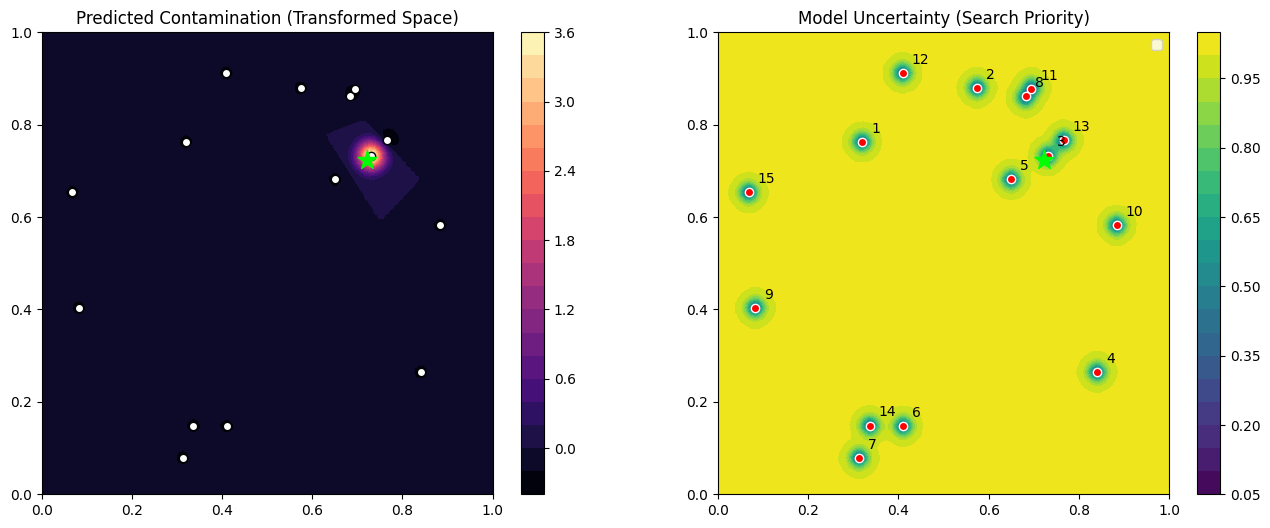

In [15]:
plot_results(model, X, best_x_next)

## New Code - 25 Feb

In [17]:
# --- 2. Preprocessing ---
# Clip negative noise to 0 to prevent scaling issues with the PowerTransformer
Y_clipped = np.clip(Y, 0, None)
pt = PowerTransformer(method='yeo-johnson', standardize=True)
Y_transformed = pt.fit_transform(Y_clipped.reshape(-1, 1)).ravel()

# --- 3. Improved Kernel & Model ---
# RationalQuadratic is like a mixture of many Matern kernels.
# It can model a very sharp "Strong Source" and a wider "Weak Source" simultaneously.
kernel = C(1.0, (1e-3, 1e3)) * RationalQuadratic(
    length_scale=0.1, 
    alpha=0.1, 
    length_scale_bounds=(1e-2, 0.5)
) + WhiteKernel(noise_level=1e-10, noise_level_bounds=(1e-12, 1e-5))

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=50, # High restarts to handle the complex alpha parameter
    normalize_y=False,
    random_state=42
)

model.fit(X, Y_transformed)
print(f"Optimized Kernel: {model.kernel_}")


Optimized Kernel: 1**2 * RationalQuadratic(alpha=1e+05, length_scale=0.0208) + WhiteKernel(noise_level=6.47e-12)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [18]:
# --- 4. Acquisition Function: Upper Confidence Bound (UCB) ---
def upper_confidence_bound(x, model, beta=3.0):
    """
    High beta (e.g., 3.0+) forces the model to look for weak sources 
    in high-uncertainty areas. Low beta (e.g., 1.0) hones in on known peaks.
    """
    mu, sigma = model.predict(x.reshape(1, -1), return_std=True)
    return mu + beta * sigma

In [23]:
# --- 5. Global Optimization of UCB ---

# Change the beta value to switch modes:
# beta = 1.0  # REFINING: Finds the exact peak of the known 10^-16 source.
# beta = 5.0  # Medium-high for "Reliable Detection"
# beta = 10.0 # HUNTING: Ignored the known source and jumps to empty corners.

def min_obj(x):
    return -upper_confidence_bound(x, model, beta=1.0)

best_x_next = None
max_ucb_val = float('-inf')

for _ in range(30):
    x_start = np.random.uniform(0, 1, size=X.shape[1])
    res = minimize(
        min_obj, 
        x0=x_start, 
        bounds=[(0, 1)] * X.shape[1], 
        method='L-BFGS-B'
    )
    if -res.fun > max_ucb_val:
        max_ucb_val = -res.fun
        best_x_next = res.x

In [28]:
# --- 6. Visualization Function ---
def plot_results(model, X_train, next_point):
    res = 100 
    x1 = np.linspace(0, 1, res)
    x2 = np.linspace(0, 1, res)
    X1, X2 = np.meshgrid(x1, x2)
    grid = np.vstack([X1.ravel(), X2.ravel()]).T
    
    mu, sigma = model.predict(grid, return_std=True)
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Predicted Mean (The "Likely Sources")
    c1 = ax[0].contourf(X1, X2, mu.reshape(X1.shape), levels=20, cmap='magma')
    ax[0].scatter(X_train[:, 0], X_train[:, 1], c='white', edgecolors='black', label='Past Samples')
    ax[0].scatter(next_point[0], next_point[1], c='lime', marker='*', s=200, label='Next Target')
    ax[0].set_title("Predicted Contamination (Transformed Space)")
    fig.colorbar(c1, ax=ax[0])
    
    # Plot 2: Uncertainty (Where weak sources might hide)
    c2 = ax[1].contourf(X1, X2, sigma.reshape(X1.shape), levels=20, cmap='viridis')
    ax[1].scatter(X_train[:, 0], X_train[:, 1], c='red', edgecolors='white')
    ax[1].scatter(next_point[0], next_point[1], c='lime', marker='*', s=200)
    ax[1].set_title("Model Uncertainty (Search Priority)")
    fig.colorbar(c2, ax=ax[1])
    
    plt.legend()
    for i, txt in enumerate(range(1, len(Y) + 1)):
        plt.annotate(txt, (X[i, 0]+0.02, X[i, 1]+0.02))

    plt.show()


In [25]:
# --- 7. Execution & Prediction ---
mu_next, sigma_next = model.predict(best_x_next.reshape(1, -1), return_std=True)
predicted_y_raw = pt.inverse_transform(mu_next.reshape(-1, 1))[0, 0]

print(f"Next candidate coordinates: {best_x_next}")
print(f"Predicted Raw Y: {predicted_y_raw:.4e}")
print(f"Submit this: {'-'.join(f'{val:.6f}' for val in best_x_next)}")


Next candidate coordinates: [0.72674584 0.72898698]
Predicted Raw Y: 2.2204e-16
Submit this: 0.726746-0.728987


C:\Users\Dave Amin\AppData\Local\Temp\ipykernel_57272\417672877.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


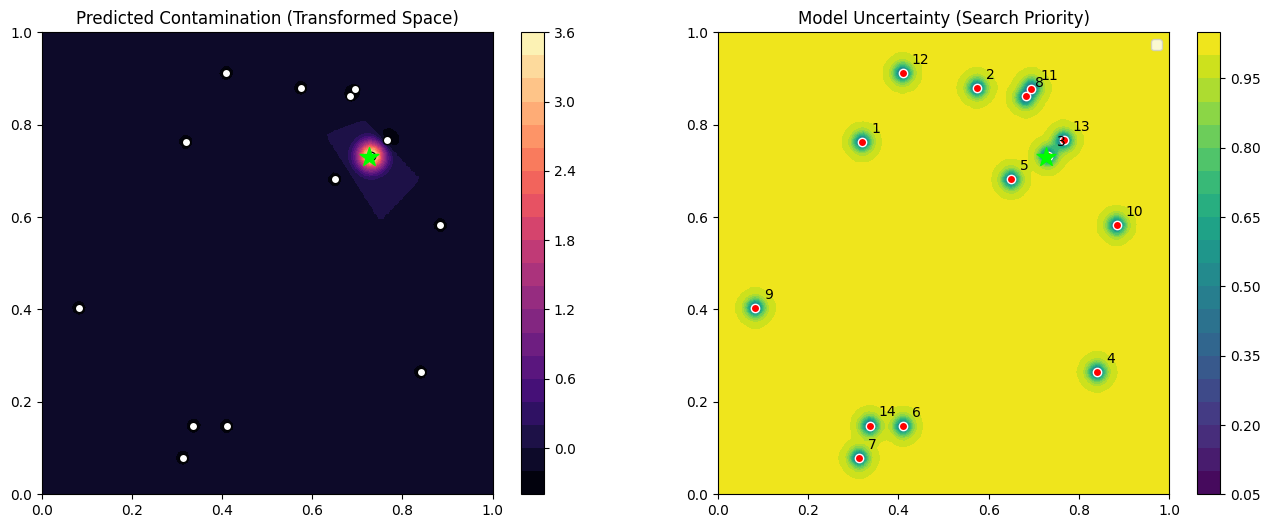

In [29]:
plot_results(model, X, best_x_next)

### Results:
#### new code with beta =5   EXPLORATION - USING THIS
Next candidate coordinates: [0.06787405 0.65342009]
Predicted Raw Y: 0.0000e+00  (unknown)
Submit this: 0.067874-0.653420
#### new code with beta =1  EXPLOITATION
Next candidate coordinates: [0.72674584 0.72898698]
Predicted Raw Y: 2.2204e-16
Submit this: 0.726746-0.728987

## Misc

In [103]:
num = 1
for i in range(0, num):
    print("count")

count
